In [2]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("statistics.xls", sheet_name="12.14.")
df.head(30)

,"12.14. Кількість внутрішньо переміщених осіб, за статтю та віковими групами (0-14 років, 15-18 років, 19-24 роки, 25-34 роки, 35-44 роки, 45-65 років, 66 років і старші), осіб",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(станом на 1 січня),NaN
2,NaN,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0,2024,2025.0
3,"Кількість внутрішньо переміщених осіб, осіб",940854.0,1632582.0,1528553.0,1475269.0,1321649.0,1412824.0,1441995.0,1478135.0,4857116.0,4894913,4640586.0
4,у тому числі за віковими групами,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0-14 років,108648.0,172546.0,192668.0,210752.0,124737.0,151067.0,152681.0,155786.0,914190.0,851024,725277.0
6,15-18 років,13864.0,26607.0,32386.0,37183.0,25663.0,30732.0,32487.0,34879.0,214020.0,228615,218661.0
7,19-24 роки,29072.0,52338.0,53220.0,56713.0,54311.0,54993.0,54346.0,53172.0,277727.0,287267,273288.0
8,25-34 роки,90623.0,148349.0,146020.0,142367.0,139741.0,145799.0,144678.0,142618.0,613682.0,562614,482636.0
9,35-44 роки,74333.0,130700.0,125742.0,124871.0,127226.0,141817.0,151347.0,162174.0,726976.0,734432,680577.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 12 columns):
 #   Column                                                                                                                                                                                         Non-Null Count  Dtype  
---  ------                                                                                                                                                                                         --------------  -----  
 0   12.14. Кількість внутрішньо переміщених осіб, за статтю та віковими групами (0-14 років, 15-18 років, 19-24 роки, 25-34 роки, 35-44 роки,  45-65 років,              66 років і старші), осіб  28 non-null     object 
 1   Unnamed: 1                                                                                                                                                                                     25 non-null     float64
 2   Unnamed: 2  

In [5]:
df = pd.read_excel("statistics.xls", sheet_name="12.14.", skiprows=3, skipfooter=1)
df.head(30)

,Unnamed: 0,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,"Кількість внутрішньо переміщених осіб, осіб",940854.0,1632582.0,1528553.0,1475269.0,1321649.0,1412824.0,1441995.0,1478135.0,4857116.0,4894913.0,4640586.0
1,у тому числі за віковими групами,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0-14 років,108648.0,172546.0,192668.0,210752.0,124737.0,151067.0,152681.0,155786.0,914190.0,851024.0,725277.0
3,15-18 років,13864.0,26607.0,32386.0,37183.0,25663.0,30732.0,32487.0,34879.0,214020.0,228615.0,218661.0
4,19-24 роки,29072.0,52338.0,53220.0,56713.0,54311.0,54993.0,54346.0,53172.0,277727.0,287267.0,273288.0
5,25-34 роки,90623.0,148349.0,146020.0,142367.0,139741.0,145799.0,144678.0,142618.0,613682.0,562614.0,482636.0
6,35-44 роки,74333.0,130700.0,125742.0,124871.0,127226.0,141817.0,151347.0,162174.0,726976.0,734432.0,680577.0
7,45-65 років,388610.0,624550.0,544185.0,492094.0,447582.0,450659.0,434361.0,424979.0,1192277.0,1220392.0,1164574.0
8,66 років і старші,235704.0,477492.0,434332.0,411289.0,402389.0,437757.0,472095.0,504527.0,918244.0,1010569.0,1095573.0
9,Жінки,549988.0,976086.0,904700.0,860138.0,785348.0,832209.0,846502.0,865659.0,2911161.0,2923937.0,2775075.0


# Women

In [6]:
women = df.loc[11:17].copy()
women.head(7)

,Unnamed: 0,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
11,0-14 років,53018.0,84471.0,94318.0,103079.0,60645.0,73318.0,74073.0,75566.0,445261.0,413624.0,352912.0
12,15-18 років,7370.0,13746.0,16550.0,18858.0,12973.0,15246.0,15982.0,17098.0,107558.0,113395.0,108247.0
13,19-24 роки,19607.0,34137.0,32755.0,33261.0,31192.0,30744.0,29501.0,28093.0,157590.0,158081.0,147029.0
14,25-34 роки,60650.0,99579.0,96841.0,91918.0,89796.0,91355.0,88970.0,86019.0,393857.0,355514.0,302633.0
15,35-44 роки,43575.0,78106.0,76138.0,75141.0,79415.0,87575.0,93132.0,99365.0,468082.0,470207.0,434859.0
16,45-65 років,212942.0,347317.0,301003.0,269077.0,245729.0,246168.0,235560.0,229418.0,723422.0,737926.0,701185.0
17,66 років і старші,152826.0,318730.0,287095.0,268804.0,265598.0,287803.0,309284.0,330100.0,615391.0,675190.0,728210.0


## By age group for each year

### Mean

In [7]:
columns_mean = women.iloc[:, 1:12].mean()
round(columns_mean, 2)

2015     78569.71
2016    139440.86
2017    129242.86
2018    122876.86
2019    112192.57
2020    118887.00
2021    120928.86
2022    123665.57
2023    415880.14
2024    417705.29
2025    396439.29
dtype: float64

### Trim mean

In [8]:
columns_trim_mean = trim_mean(women.iloc[:, 1:12], 0.15)
rez_columns_trim_mean = pd.Series(columns_trim_mean, index = women.columns[1:12])
rez_columns_trim_mean

2015     65935.2
2016    123004.6
2017    117429.4
2018    114440.6
2019    101355.4
2020    105832.0
2021    104247.2
2022    103692.2
2023    416036.2
2024    414523.2
2025    387723.6
dtype: float64

### Median

In [9]:
columns_median = women.iloc[:, 1:12].median()
round(columns_median, 2)

2015     53018.0
2016     84471.0
2017     94318.0
2018     91918.0
2019     79415.0
2020     87575.0
2021     88970.0
2022     86019.0
2023    445261.0
2024    413624.0
2025    352912.0
dtype: float64

### Standart deviation

In [10]:
columns_std = women.iloc[:, 1:12].std()
round(columns_std, 2)

2015     75624.67
2016    135780.34
2017    116560.56
2018    104202.73
2019    101656.24
2020    105718.73
2021    109529.57
2022    114463.14
2023    223694.81
2024    236463.54
2025    245075.62
dtype: float64

### Variance

In [11]:
columns_var = women.iloc[:, 1:12].var()
columns_var

2015    5.719091e+09
2016    1.843630e+10
2017    1.358636e+10
2018    1.085821e+10
2019    1.033399e+10
2020    1.117645e+10
2021    1.199673e+10
2022    1.310181e+10
2023    5.003937e+10
2024    5.591501e+10
2025    6.006206e+10
dtype: float64

### Quantile

In [12]:
columns_quantile = women.iloc[:, 1:12].quantile(0.95)
columns_quantile

2015    194907.2
2016    338740.9
2017    296830.6
2018    268995.1
2019    259637.3
2020    275312.5
2021    287166.8
2022    299895.4
2023    691012.7
2024    719105.2
2025    720102.5
Name: 0.95, dtype: float64

### IQR

In [13]:
q25c = women.iloc[:, 1:12].quantile(0.25)
q75c = women.iloc[:, 1:12].quantile(0.75)
columns_iqr = q75c - q25c
columns_iqr

2015     75147.0
2016    153033.0
2017    137521.5
2018    131740.5
2019    121844.0
2020    116730.5
2021    112559.0
2022    112562.0
2023    266013.0
2024    315901.0
2025    343191.0
dtype: float64

### Range

In [14]:
cmax = women.iloc[:, 1:12].max()
cmin = women.iloc[:, 1:12].min()
crange = cmax - cmin
crange

2015    205572.0
2016    333571.0
2017    284453.0
2018    250219.0
2019    252625.0
2020    272557.0
2021    293302.0
2022    313002.0
2023    615864.0
2024    624531.0
2025    619963.0
dtype: float64

### MAD

In [15]:
cmad = robust.scale.mad(women.iloc[:, 1:12])
rez_columns_mad = pd.Series(cmad, index = women.columns[1:12])
round(rez_columns_mad, 2)

2015     49535.22
2016     74625.30
2017     91273.44
2018     86965.00
2019     71495.53
2020     84257.77
2021     88168.87
2022     85881.22
2023    252235.12
2024    378868.62
2025    305242.59
dtype: float64

In [16]:
cmax

2015    212942.0
2016    347317.0
2017    301003.0
2018    269077.0
2019    265598.0
2020    287803.0
2021    309284.0
2022    330100.0
2023    723422.0
2024    737926.0
2025    728210.0
dtype: float64

In [17]:
cmin

2015      7370.0
2016     13746.0
2017     16550.0
2018     18858.0
2019     12973.0
2020     15246.0
2021     15982.0
2022     17098.0
2023    107558.0
2024    113395.0
2025    108247.0
dtype: float64

## From years for each age group

### Mean

In [18]:
rows_mean = women.set_index(women.columns[0]).mean(axis=1)
round(rows_mean, 2)

Unnamed: 0
0-14 років           166389.55
15-18 років           40638.45
19-24 роки            63817.27
25-34 роки           159739.27
35-44 роки           182326.82
45-65 років          386340.64
66 років і старші    385366.45
dtype: float64

### Trim mean

In [19]:
rows_trim_mean = trim_mean(women.iloc[:, 1:13].T, 0.10)
rez_columns_trim_mean = pd.Series(rows_trim_mean, index = women.iloc[:, 0])
round(rez_columns_trim_mean, 2)

Unnamed: 0
0-14 років           148000.67
15-18 років           36250.89
19-24 роки            58255.78
25-34 роки           144736.11
35-44 роки           165757.00
45-65 років          366542.11
66 років і старші    373110.56
dtype: float64

### Median

In [20]:
rows_median = women.set_index(women.columns[0]).median(axis=1)
round(rows_median, 2)

Unnamed: 0
0-14 років            84471.0
15-18 років           16550.0
19-24 роки            32755.0
25-34 роки            91918.0
35-44 роки            87575.0
45-65 років          269077.0
66 років і старші    309284.0
dtype: float64

### Standart deviation

In [21]:
rows_std = women.set_index(women.columns[0]).std(axis=1)
round(rows_std, 2)

Unnamed: 0
0-14 років           154617.77
15-18 років           44496.67
19-24 роки            58266.00
25-34 роки           124724.81
35-44 роки           177648.41
45-65 років          218120.56
66 років і старші    192071.93
dtype: float64

### Variance

In [22]:
rows_var = women.set_index(women.columns[0]).var(axis=1)
rows_var

Unnamed: 0
0-14 років           2.390666e+10
15-18 років          1.979954e+09
19-24 роки           3.394926e+09
25-34 роки           1.555628e+10
35-44 роки           3.155896e+10
45-65 років          4.757658e+10
66 років і старші    3.689163e+10
dtype: float64

### Quantile

In [23]:
rows_quantile = women.set_index(women.columns[0]).quantile(0.99, axis=1)
rows_quantile

Unnamed: 0
0-14 років           442097.3
15-18 років          112880.2
19-24 роки           158031.9
25-34 роки           390022.7
35-44 роки           469994.5
45-65 років          736475.6
66 років і старші    722908.0
Name: 0.99, dtype: float64

### IQR

In [24]:
rows_data = women.set_index(women.columns[0]).iloc[:, 0:11]
q25r = rows_data.quantile(0.25, axis=1)
q75r = rows_data.quantile(0.75, axis=1)
rows_iqr = q75r - q25r
rows_iqr

Unnamed: 0
0-14 років           154300.0
15-18 років           48712.0
19-24 роки            60460.5
25-34 роки           111723.0
35-44 роки           189990.0
45-65 років          283606.5
66 років і старші    194796.0
dtype: float64

### Range

In [25]:
rmax = women.set_index(women.columns[0]).iloc[:, 0:11].max(axis=1)
rmin = women.set_index(women.columns[0]).iloc[:, 0:11].min(axis=1)
rrange = rmax - rmin
rrange

Unnamed: 0
0-14 років           392243.0
15-18 років          106025.0
19-24 роки           138474.0
25-34 роки           333207.0
35-44 роки           426632.0
45-65 років          524984.0
66 років і старші    575384.0
dtype: float64

### Mad

In [26]:
rmad = robust.scale.mad(women.set_index(women.columns[0]), axis=1)
rez_columns_mad = pd.Series(rmad, index = women.iloc[:, 0])
round(rez_columns_mad, 2)

Unnamed: 0
0-14 років           27588.26
15-18 років           4157.22
19-24 роки            4824.39
25-34 роки            8745.87
35-44 роки           17479.88
45-65 років          58798.52
66 років і старші    60015.74
dtype: float64

# Men

In [57]:
men = df.loc[20:26].copy()
men.head(7)

,Unnamed: 0,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
20,0-14 років,55630.0,88075.0,98350.0,107673.0,64092.0,77749.0,78608.0,80220.0,468929.0,437400.0,372365.0
21,15-18 років,6494.0,12861.0,15836.0,18325.0,12690.0,15486.0,16505.0,17781.0,106462.0,115220.0,110414.0
22,19-24 роки,9465.0,18201.0,20465.0,23452.0,23119.0,24249.0,24845.0,25079.0,120137.0,129186.0,126259.0
23,25-34 роки,29973.0,48770.0,49179.0,50449.0,49945.0,54444.0,55708.0,56599.0,219825.0,207100.0,180003.0
24,35-44 роки,30758.0,52594.0,49604.0,49730.0,47811.0,54242.0,58215.0,62809.0,258894.0,264225.0,245718.0
25,45-65 років,175668.0,277233.0,243182.0,223017.0,201853.0,204491.0,198801.0,195561.0,468855.0,482466.0,463389.0
26,66 років і старші,82878.0,158762.0,147237.0,142485.0,136791.0,149954.0,162811.0,174427.0,302853.0,335379.0,367363.0


## By age group for each year

### Mean

In [58]:
columns_mean_men = men.iloc[:, 1:12].mean()
round(columns_mean_men, 2)

2015     55838.00
2016     93785.14
2017     89121.86
2018     87875.86
2019     76614.43
2020     82945.00
2021     85070.43
2022     87496.57
2023    277993.57
2024    281568.00
2025    266501.57
dtype: float64

### Trim mean

In [59]:
columns_trim_mean_men = trim_mean(men.iloc[:, 1:12], 0.15)
rez_columns_trim_mean_men = pd.Series(columns_trim_mean_men, index = men.columns[1:12])
rez_columns_trim_mean_men

2015     41740.8
2016     73280.4
2017     72967.0
2018     74757.8
2019     64351.6
2020     72127.6
2021     76037.4
2022     79826.8
2023    274112.8
2024    274658.0
2025    258341.6
dtype: float64

### Meadian

In [60]:
columns_median_men = men.iloc[:, 1:12].median()
columns_median_men

2015     30758.0
2016     52594.0
2017     49604.0
2018     50449.0
2019     49945.0
2020     54444.0
2021     58215.0
2022     62809.0
2023    258894.0
2024    264225.0
2025    245718.0
dtype: float64

### Standart deviation

In [61]:
columns_std_men = men.iloc[:, 1:12].std()
round(columns_std_men, 2)

2015     59123.77
2016     94773.82
2017     82096.21
2018     74700.34
2019     68254.08
2020     69429.51
2021     69440.25
2022     70247.32
2023    148094.88
2024    143919.79
2025    136680.91
dtype: float64

### Variance

In [62]:
columns_var_men = men.iloc[:, 1:12].var()
columns_var_men

2015    3.495621e+09
2016    8.982078e+09
2017    6.739788e+09
2018    5.580141e+09
2019    4.658620e+09
2020    4.820457e+09
2021    4.821948e+09
2022    4.934686e+09
2023    2.193209e+10
2024    2.071291e+10
2025    1.868167e+10
dtype: float64

### Quantile

In [63]:
columns_quantile_men = men.iloc[:, 1:12].quantile(0.95)
columns_quantile_men

2015    147831.0
2016    241691.7
2017    214398.5
2018    198857.4
2019    182334.4
2020    188129.9
2021    188004.0
2022    189220.8
2023    468906.8
2024    468946.2
2025    436081.8
Name: 0.95, dtype: float64

### IQR

In [64]:
q25c_men = men.iloc[:, 1:12].quantile(0.25)
q75c_men = men.iloc[:, 1:12].quantile(0.75)
columns_iqr_men = q75c_men - q25c_men
columns_iqr_men

2015     49535.0
2016     89933.0
2017     87971.5
2018     88488.0
2019     64976.5
2020     74606.0
2021     80433.0
2022     86484.5
2023    215873.0
2024    218246.5
2025    216733.0
dtype: float64

### Range

In [65]:
cmax_men = men.iloc[:, 1:12].max()
cmin_men = men.iloc[:, 1:12].min()
crange_men = cmax_men - cmin_men
crange_men

2015    169174.0
2016    264372.0
2017    227346.0
2018    204692.0
2019    189163.0
2020    189005.0
2021    182296.0
2022    177780.0
2023    362467.0
2024    367246.0
2025    352975.0
dtype: float64

### MAD

In [66]:
cmad_men = robust.scale.mad(men.iloc[:, 1:12])
rez_columns_mad_men = pd.Series(cmad_men, index = men.columns[1:12])
round(rez_columns_mad_men, 2)

2015     35973.86
2016     52604.21
2017     50064.51
2018     47627.11
2019     39772.29
2020     44767.17
2021     49474.44
2022     55938.58
2023    205721.44
2024    200209.12
2025    180351.15
dtype: float64

## From years for each age group

### Mean

In [67]:
rows_mean_men = men.set_index(men.columns[0]).mean(axis=1)
round(rows_mean_men, 2)

Unnamed: 0
0-14 років           175371.91
15-18 років           40734.00
19-24 роки            49496.09
25-34 роки            91090.45
35-44 роки           106781.82
45-65 років          284956.00
66 років і старші    196449.09
dtype: float64

### Trim mean

In [68]:
rows_trim_mean_men = trim_mean(men.iloc[:, 1:13].T, 0.10)
rez_columns_trim_mean_men = pd.Series(rows_trim_mean_men, index = men.iloc[:, 0])
round(rez_columns_trim_mean_men, 2)

Unnamed: 0
0-14 років           156059.11
15-18 років           36262.22
19-24 роки            45089.56
25-34 роки            83577.44
35-44 роки            97735.22
45-65 років          275153.56
66 років і старші    190077.67
dtype: float64

### Median

In [69]:
rows_median_men = men.set_index(men.columns[0]).median(axis=1)
rows_median_men

Unnamed: 0
0-14 років            88075.0
15-18 років           16505.0
19-24 роки            24249.0
25-34 роки            54444.0
35-44 роки            54242.0
45-65 років          223017.0
66 років і старші    158762.0
dtype: float64

### Standart deviation

In [70]:
rows_std_men = men.set_index(men.columns[0]).std(axis=1)
round(rows_std_men, 2)

Unnamed: 0
0-14 років           163231.66
15-18 років           45091.91
19-24 роки            48860.18
25-34 роки            72352.19
35-44 роки            96436.62
45-65 років          122901.29
66 років і старші     93179.89
dtype: float64

### Variance

In [71]:
rows_var_men = men.set_index(men.columns[0]).var(axis=1)
rows_var_men

Unnamed: 0
0-14 років           2.664457e+10
15-18 років          2.033280e+09
19-24 роки           2.387317e+09
25-34 роки           5.234839e+09
35-44 роки           9.300022e+09
45-65 років          1.510473e+10
66 років і старші    8.682491e+09
dtype: float64

### Quantile

In [72]:
rows_quantile_men = men.set_index(men.columns[0]).quantile(0.99, axis=1)
rows_quantile_men

Unnamed: 0
0-14 років           465776.1
15-18 років          114739.4
19-24 роки           128893.3
25-34 роки           218552.5
35-44 роки           263691.9
45-65 років          481104.9
66 років і старші    364164.6
Name: 0.99, dtype: float64

### IQR

In [73]:
rows_data_men = men.set_index(men.columns[0]).iloc[:, 0:11]
q25r_men = rows_data_men.quantile(0.25, axis=1)
q75r_men = rows_data_men.quantile(0.75, axis=1)
rows_iqr_men = q75r_men - q25r_men
rows_iqr_men

Unnamed: 0
0-14 років           161840.5
15-18 років           48220.0
19-24 роки            50816.0
25-34 роки            68739.0
35-44 роки           104596.5
45-65 років          169984.0
66 років і старші     93779.0
dtype: float64

### Range

In [74]:
rmax_men = men.set_index(men.columns[0]).iloc[:, 0:11].max(axis=1)
rmin_men = men.set_index(men.columns[0]).iloc[:, 0:11].min(axis=1)
rrange_men = rmax_men - rmin_men
rrange_men

Unnamed: 0
0-14 років           413299.0
15-18 років          108726.0
19-24 роки           119721.0
25-34 роки           189852.0
35-44 роки           233467.0
45-65 років          306798.0
66 років і старші    284485.0
dtype: float64

### Mad

In [75]:
rmad_men = robust.scale.mad(men.set_index(men.columns[0]), axis=1)
rez_columns_mad_men = pd.Series(rmad_men, index = men.iloc[:, 0])
round(rez_columns_mad_men, 2)

Unnamed: 0
0-14 років           29056.04
15-18 років           5402.60
19-24 роки            5610.17
25-34 роки            7805.90
35-44 роки            9534.61
45-65 років          40706.33
66 років і старші    24132.32
dtype: float64

# Data Visualisation

<Axes: title={'center': 'Graph of IDPs among men aged 25-34 from 2015 to 2025'}, xlabel='Year', ylabel='Population'>

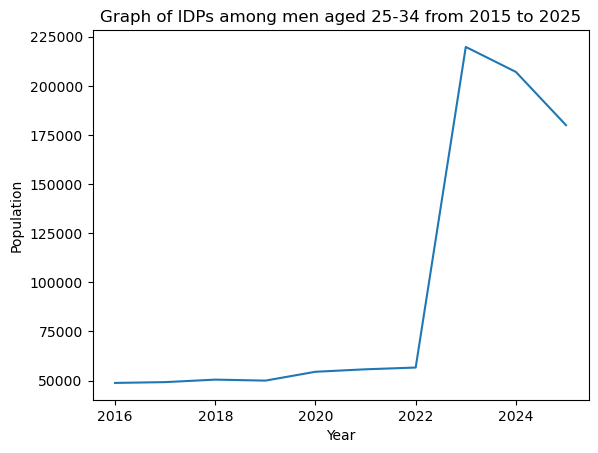

In [76]:
men.set_index(men.columns[0]).iloc[3, 1:12].plot(
    title = 'Graph of IDPs among men aged 25-34 from 2015 to 2025',
    ylabel = 'Population',
    xlabel = 'Year'
)

(array([1, 2, 3, 4, 5, 6, 7]),
 [Text(1, 0, '      0-14 років'),
  Text(2, 0, '      15-18 років'),
  Text(3, 0, '      19-24 роки'),
  Text(4, 0, '      25-34 роки'),
  Text(5, 0, '      35-44 роки'),
  Text(6, 0, '      45-65 років'),
  Text(7, 0, '      66 років і старші')])

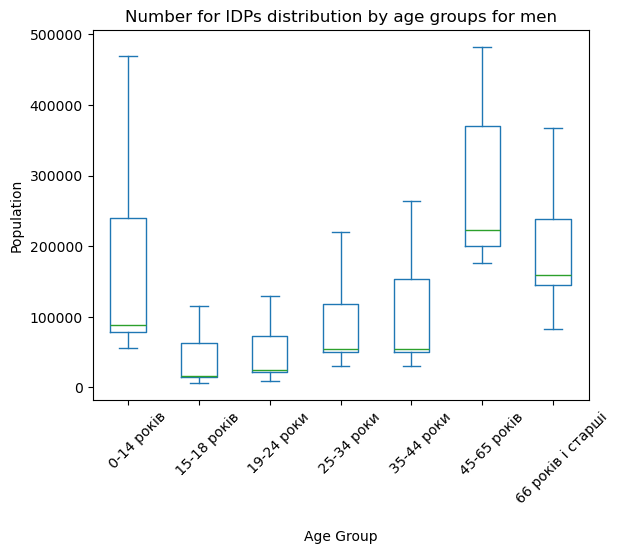

In [77]:
men.set_index(men.columns[0]).T.plot.box(
    title = 'Number for IDPs distribution by age groups for men',
    ylabel = 'Population',
    xlabel = 'Age Group'
)
plt.xticks(rotation=45)

<Axes: title={'center': 'Number of IDPs for men, 2025'}, xlabel='Age group', ylabel='Population'>

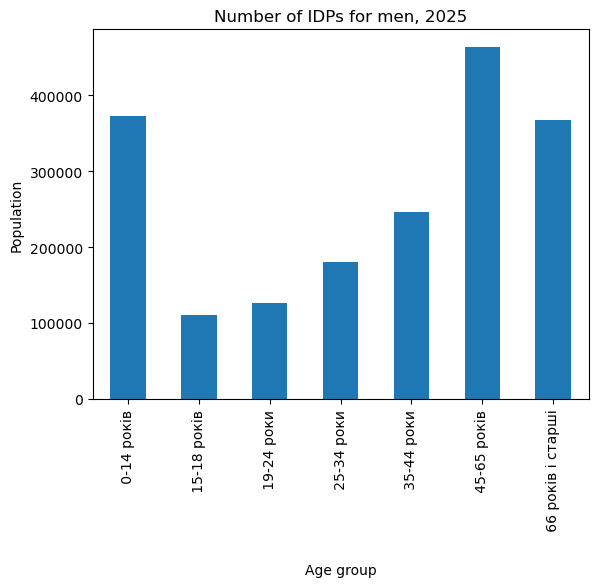

In [78]:
men.set_index(men.columns[0]).iloc[:, -1].plot.bar(
    title = 'Number of IDPs for men, 2025',
    ylabel = 'Population',
    xlabel = 'Age group'
)

<Axes: title={'center': 'Graph of IDPs among women aged 25-34 from 2015 to 2025'}, xlabel='Year', ylabel='Population'>

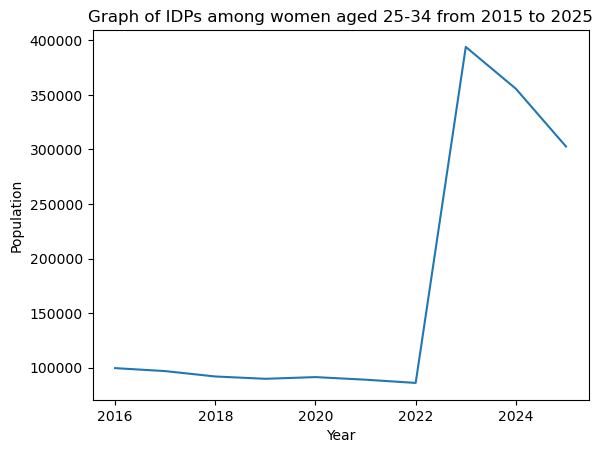

In [79]:
women_group25_34 = women.set_index(women.columns[0]).iloc[3, 1:12]
women_group25_34.plot(
    title = 'Graph of IDPs among women aged 25-34 from 2015 to 2025',
    ylabel = 'Population',
    xlabel = 'Year'
)

(array([1, 2, 3, 4, 5, 6, 7]),
 [Text(1, 0, '      0-14 років'),
  Text(2, 0, '      15-18 років'),
  Text(3, 0, '      19-24 роки'),
  Text(4, 0, '      25-34 роки'),
  Text(5, 0, '      35-44 роки'),
  Text(6, 0, '      45-65 років'),
  Text(7, 0, '      66 років і старші')])

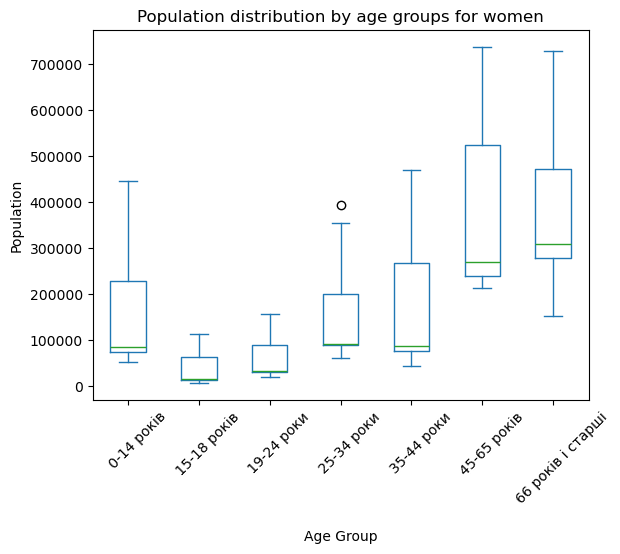

In [80]:
women.set_index(women.columns[0]).T.plot.box(
    title = 'Population distribution by age groups for women',
    ylabel = 'Population',
    xlabel = 'Age Group'
)
plt.xticks(rotation=45)

<Axes: title={'center': 'Number of IDPs for men, 2025'}, xlabel='Age group', ylabel='Population'>

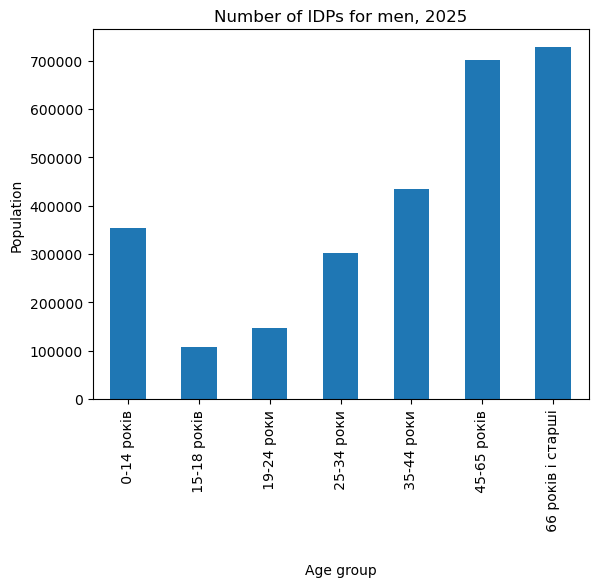

In [81]:
women.set_index(women.columns[0]).iloc[:, -1].plot.bar(
    title = 'Number of IDPs for men, 2025',
    ylabel = 'Population',
    xlabel = 'Age group'
)

### Correlation matrix

In [82]:
women.set_index(women.columns[0]).iloc[:, 0:11].T.corr()

Unnamed: 0,0-14 років,15-18 років,19-24 роки,25-34 роки,35-44 роки,45-65 років,66 років і старші
Unnamed: 0,,,,,,,
0-14 років,1.000000,0.989147,0.993834,0.997282,0.990779,0.984923,0.942235
15-18 років,0.989147,1.000000,0.997885,0.984358,0.997597,0.986155,0.971863
19-24 роки,0.993834,0.997885,1.000000,0.992085,0.997631,0.991512,0.965134
25-34 роки,0.997282,0.984358,0.992085,1.000000,0.990282,0.982344,0.940169
35-44 роки,0.990779,0.997597,0.997631,0.990282,1.000000,0.983315,0.969556
45-65 років,0.984923,0.986155,0.991512,0.982344,0.983315,1.000000,0.961969
66 років і старші,0.942235,0.971863,0.965134,0.940169,0.969556,0.961969,1.000000


In [83]:
men.set_index(men.columns[0]).iloc[:, 0:11].T.corr()

Unnamed: 0,0-14 років,15-18 років,19-24 роки,25-34 роки,35-44 роки,45-65 років,66 років і старші
Unnamed: 0,,,,,,,
0-14 років,1.000000,0.986638,0.982669,0.995396,0.990709,0.977027,0.934713
15-18 років,0.986638,1.000000,0.999092,0.988585,0.997773,0.976552,0.970866
19-24 роки,0.982669,0.999092,1.000000,0.988222,0.997364,0.972526,0.974831
25-34 роки,0.995396,0.988585,0.988222,1.000000,0.995238,0.969687,0.947995
35-44 роки,0.990709,0.997773,0.997364,0.995238,1.000000,0.976642,0.967476
45-65 років,0.977027,0.976552,0.972526,0.969687,0.976642,1.000000,0.953301
66 років і старші,0.934713,0.970866,0.974831,0.947995,0.967476,0.953301,1.000000
